# Rolex Watch Price Analysis - Part 4: Statistical Analysis
## Final Project - Data Analytics

## Libraries and settings

In [15]:
import os
import numpy as np
import pandas as pd
import scipy.stats as stats
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import f_oneway, chi2_contingency, pearsonr

import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

print(os.getcwd())

/Users/adisaljusi/repos/data_analytics/final


## Import Cleaned Data

In [16]:
df = pd.read_csv('rolex_data_cleaned.csv', encoding='utf-8')

print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (2373, 19)


,web_scraper_order,brand_raw,model_raw,reference_number_raw,movement_type,condition_category,seller_type,case_material_clean,bracelet_material_clean,material_category,country,city,price,year,age,has_box,has_papers,has_complete_set,is_professional
0,1766787541-2,Rolex,Datejust 31,278274,Automatic,New,Professional dealer,Steel,Steel,Steel,Netherlands,Franeker,11415.0,2023.0,1.0,1,1,1,1
1,1766787544-3,Rolex,Cellini Danaos,4233,Manual,Fair,Professional dealer,Rose gold,Unknown,Rose Gold,United States of America,New York City,5248.0,2010.0,14.0,1,1,1,1
2,1766787546-4,Rolex,GMT-Master II,126720VTNR,Automatic,Very Good,Partner Certified Included,Steel,Steel,Steel,Netherlands,Franeker,14745.0,2024.0,0.0,1,1,1,0
3,1766787548-5,Rolex,Sea-Dweller,1665\n \n ...,Automatic,Very Good,Professional dealer,Steel,Steel,Steel,United States of America,Colorado,23009.0,1979.0,45.0,1,1,1,1
4,1766787550-6,Rolex,Explorer,124270\n \n ...,Automatic,Very Good,Partner Certified Included,Steel,Steel,Steel,Netherlands,Franeker,7132.0,2022.0,2.0,1,1,1,0


## 1. Correlation Analysis with P-Values

### 1.1 Price vs Age Correlation

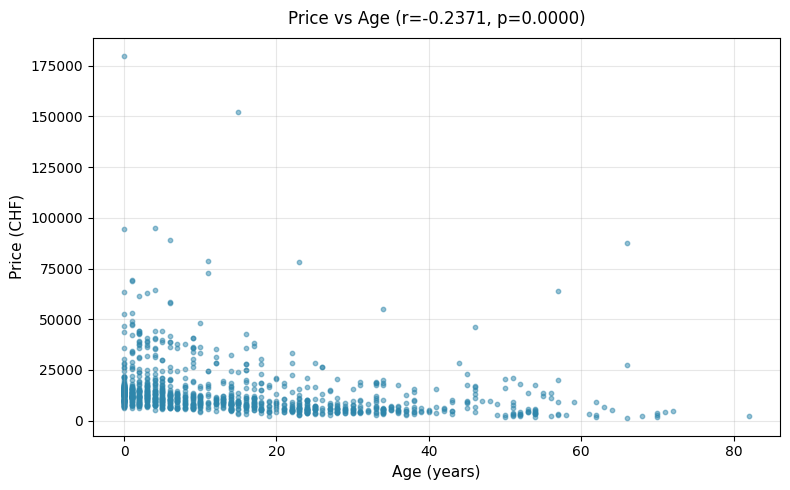

Pearson Correlation Analysis: Price vs Age
  Correlation coefficient (r): -0.2371
  p-value: 0.000000

Interpretation:
  There is a statistically significant negative correlation between age and price (p < 0.05).
  Older watches tend to have lower prices.


In [17]:
df_clean = df[['price', 'age']].dropna()

r, p_value = pearsonr(df_clean['age'], df_clean['price'])

plt.figure(figsize=(8, 5))
plt.scatter(df_clean['age'], df_clean['price'], s=10, alpha=0.5, color='#2E86AB')
plt.xlabel('Age (years)', fontsize=11)
plt.ylabel('Price (CHF)', fontsize=11)
plt.title(f'Price vs Age (r={r:.4f}, p={p_value:.4f})', fontsize=12, pad=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Pearson Correlation Analysis: Price vs Age")
print(f"  Correlation coefficient (r): {r:.4f}")
print(f"  p-value: {p_value:.6f}")
print(f"\nInterpretation:")
if p_value < 0.05:
    if r > 0:
        print(f"  There is a statistically significant positive correlation between age and price (p < 0.05).")
        print(f"  Older watches tend to have higher prices.")
    else:
        print(f"  There is a statistically significant negative correlation between age and price (p < 0.05).")
        print(f"  Older watches tend to have lower prices.")
else:
    print(f"  There is no statistically significant correlation between age and price (p >= 0.05).")

### 1.2 Price vs Year Correlation

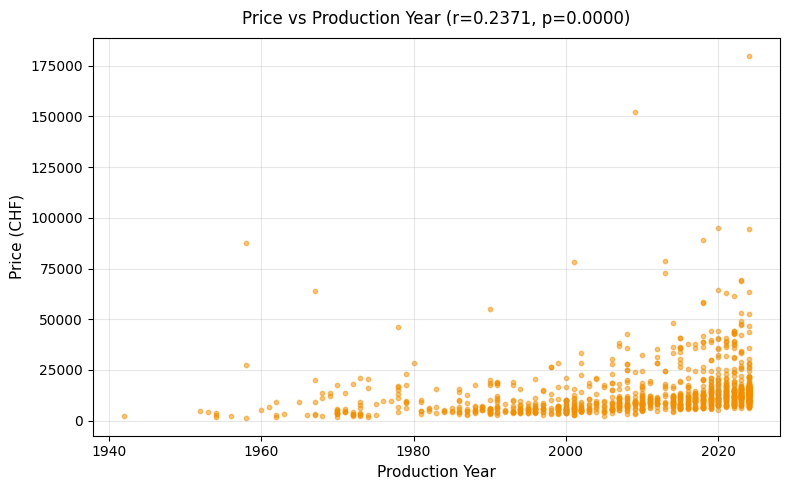

Pearson Correlation Analysis: Price vs Production Year
  Correlation coefficient (r): 0.2371
  p-value: 0.000000

Interpretation:
  There is a statistically significant positive correlation between production year and price (p < 0.05).
  Newer watches tend to have higher prices.


In [18]:
df_clean2 = df[['price', 'year']].dropna()

r2, p_value2 = pearsonr(df_clean2['year'], df_clean2['price'])

plt.figure(figsize=(8, 5))
plt.scatter(df_clean2['year'], df_clean2['price'], s=10, alpha=0.5, color='#F18F01')
plt.xlabel('Production Year', fontsize=11)
plt.ylabel('Price (CHF)', fontsize=11)
plt.title(f'Price vs Production Year (r={r2:.4f}, p={p_value2:.4f})', fontsize=12, pad=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Pearson Correlation Analysis: Price vs Production Year")
print(f"  Correlation coefficient (r): {r2:.4f}")
print(f"  p-value: {p_value2:.6f}")
print(f"\nInterpretation:")
if p_value2 < 0.05:
    if r2 > 0:
        print(f"  There is a statistically significant positive correlation between production year and price (p < 0.05).")
        print(f"  Newer watches tend to have higher prices.")
    else:
        print(f"  There is a statistically significant negative correlation between production year and price (p < 0.05).")
        print(f"  Newer watches tend to have lower prices.")
else:
    print(f"  There is no statistically significant correlation between production year and price (p >= 0.05).")

### 1.3 Correlation Matrix for Numerical Variables

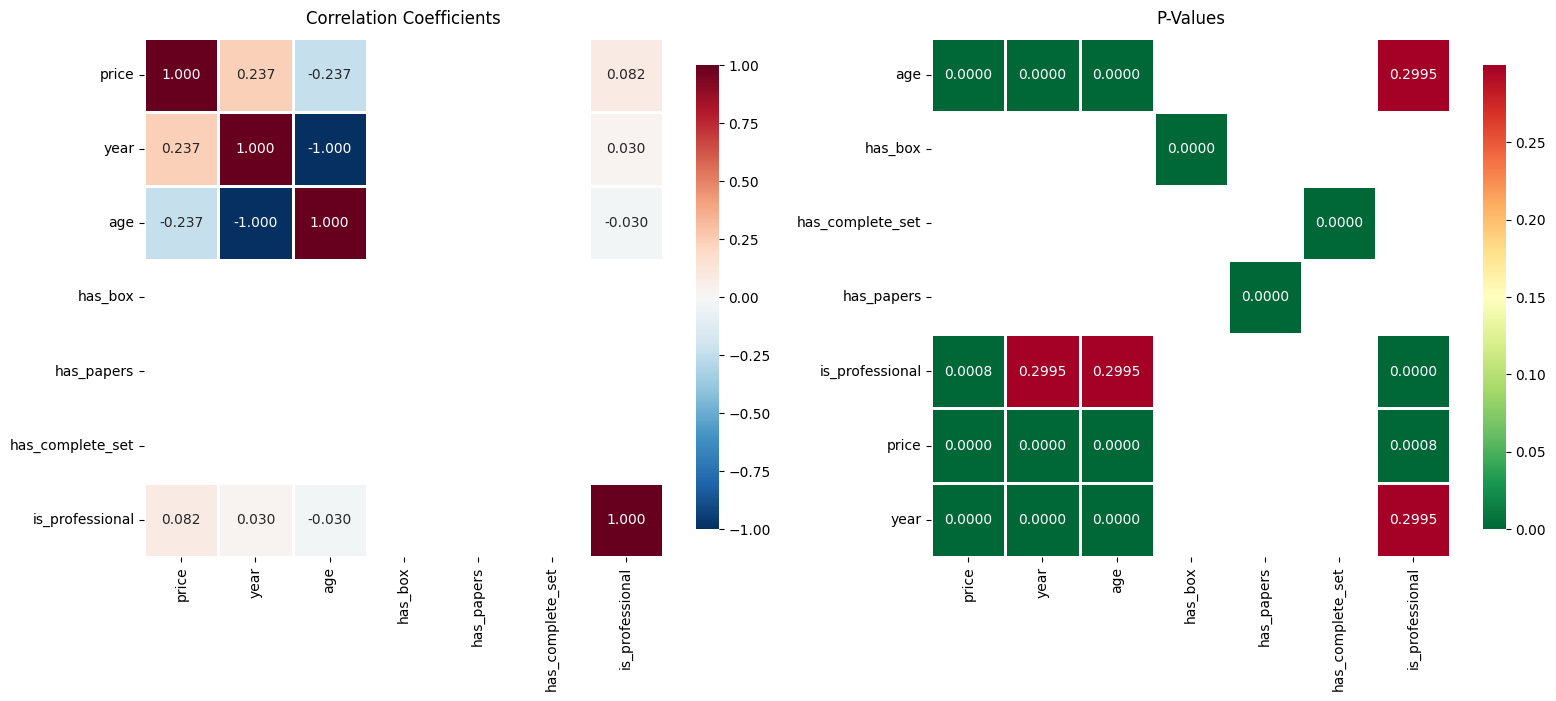


Correlation with Price (sorted by absolute value):
  age                 : r=-0.2371, p=0.000000 ***
  year                : r= 0.2371, p=0.000000 ***
  is_professional     : r= 0.0818, p=0.000796 ***
  has_box             : r=    nan, p=nan n.s.
  has_papers          : r=    nan, p=nan n.s.
  has_complete_set    : r=    nan, p=nan n.s.


In [19]:
numerical_cols = ['price', 'year', 'age', 'has_box', 'has_papers', 'has_complete_set', 'is_professional']

corr_matrix = df[numerical_cols].corr()

def calculate_pvalues(df_in):
    df_temp = df_in.dropna()
    dfcols = pd.DataFrame(columns=df_temp.columns)
    pvalues = dfcols.transpose().join(dfcols, how='outer')
    for r in df_temp.columns:
        for c in df_temp.columns:
            if r != c:
                pvalues[r][c] = pearsonr(df_temp[r], df_temp[c])[1]
            else:
                pvalues[r][c] = 0
    return pvalues

pvalues = calculate_pvalues(df[numerical_cols])

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='RdBu_r', center=0, 
            square=True, linewidths=1, ax=axes[0], cbar_kws={"shrink": 0.8})
axes[0].set_title('Correlation Coefficients', fontsize=12, pad=10)

sns.heatmap(pvalues.astype(float), annot=True, fmt='.4f', cmap='RdYlGn_r', 
            square=True, linewidths=1, ax=axes[1], cbar_kws={"shrink": 0.8})
axes[1].set_title('P-Values', fontsize=12, pad=10)

plt.tight_layout()
plt.show()

print("\nCorrelation with Price (sorted by absolute value):")
price_corr = corr_matrix['price'].sort_values(key=abs, ascending=False)
for var in price_corr.index:
    if var != 'price':
        p_val = pvalues.loc[var, 'price']
        sig = "***" if p_val < 0.001 else "**" if p_val < 0.01 else "*" if p_val < 0.05 else "n.s."
        print(f"  {var:20s}: r={price_corr[var]:7.4f}, p={p_val:.6f} {sig}")

### Interpretation

The correlation analysis reveals which numerical variables have statistically significant linear relationships with price. Variables with p-values < 0.05 show significant correlations. The strength of the relationship is indicated by the correlation coefficient (r), where values closer to 1 or -1 indicate stronger relationships.

## 2. ANOVA Test: Price Differences Across Conditions

### 2.1 One-Way ANOVA for Condition Categories

<Figure size 1200x600 with 0 Axes>

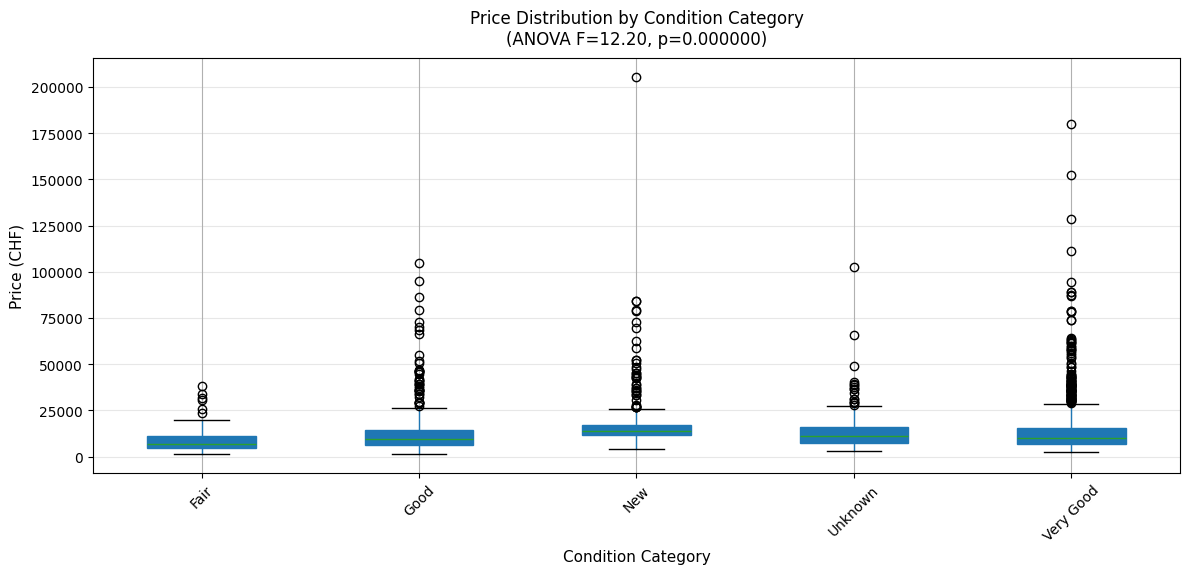

One-Way ANOVA: Price Differences Across Condition Categories
  F-statistic: 12.2025
  p-value: 0.000000

Descriptive Statistics by Condition:
                        mean   median       std  count
condition_category                                    
Fair                 8781.09   7024.0   6765.64    119
Good                12719.95   9267.0  12605.43    497
New                 17768.77  13927.0  15680.99    345
Unknown             14104.46  10930.5  11764.43    162
Very Good           13925.00  10088.0  13971.49   1250

Interpretation:
  There are statistically significant price differences across condition categories (p < 0.05).
  The condition of a watch significantly affects its price.
  At least one condition category has a significantly different mean price than the others.


In [20]:
condition_groups = [group['price'].values for name, group in df.groupby('condition_category') if len(group) >= 2]
condition_names = [name for name, group in df.groupby('condition_category') if len(group) >= 2]

f_statistic, p_value_anova = f_oneway(*condition_groups)

plt.figure(figsize=(12, 6))
df.boxplot(column='price', by='condition_category', figsize=(12, 6), patch_artist=True)
plt.suptitle('')
plt.title(f'Price Distribution by Condition Category\n(ANOVA F={f_statistic:.2f}, p={p_value_anova:.6f})', 
          fontsize=12, pad=10)
plt.xlabel('Condition Category', fontsize=11)
plt.ylabel('Price (CHF)', fontsize=11)
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print(f"One-Way ANOVA: Price Differences Across Condition Categories")
print(f"  F-statistic: {f_statistic:.4f}")
print(f"  p-value: {p_value_anova:.6f}")
print(f"\nDescriptive Statistics by Condition:")
condition_stats = df.groupby('condition_category')['price'].agg(['mean', 'median', 'std', 'count'])
print(condition_stats.round(2))
print(f"\nInterpretation:")
if p_value_anova < 0.05:
    print(f"  There are statistically significant price differences across condition categories (p < 0.05).")
    print(f"  The condition of a watch significantly affects its price.")
    print(f"  At least one condition category has a significantly different mean price than the others.")
else:
    print(f"  There are no statistically significant price differences across condition categories (p >= 0.05).")
    print(f"  The condition does not significantly affect the price.")

### 2.2 ANOVA for Material Categories

<Figure size 1200x600 with 0 Axes>

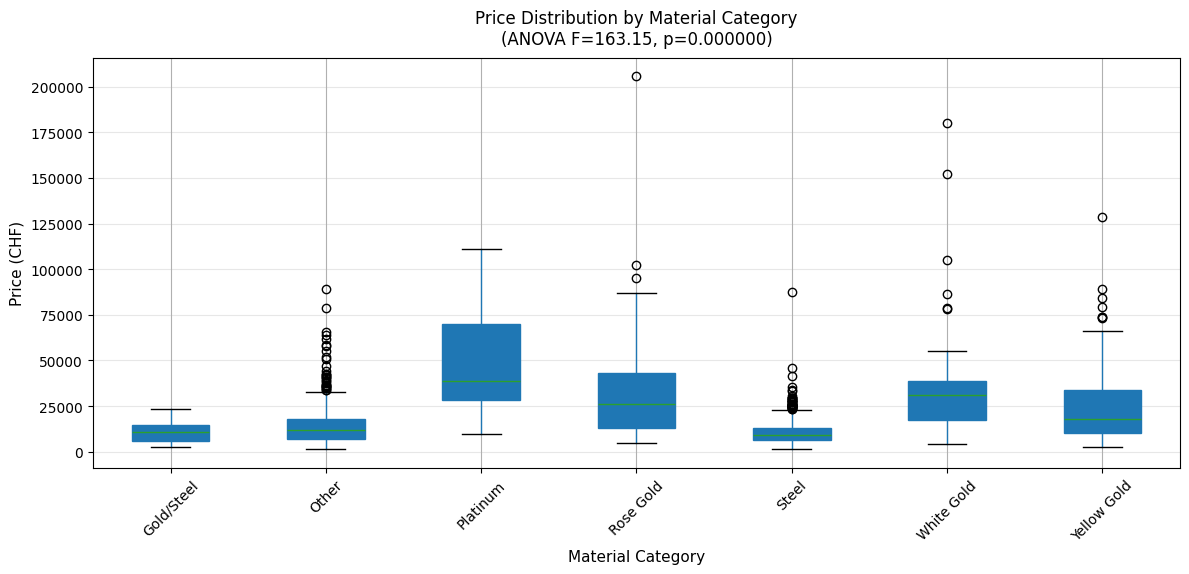

One-Way ANOVA: Price Differences Across Material Categories
  F-statistic: 163.1469
  p-value: 0.000000

Descriptive Statistics by Material:
                       mean   median       std  count
material_category                                    
Gold/Steel         10675.27  10762.5   4965.99    302
Other              15973.35  12076.0  13853.47    249
Platinum           51117.21  38699.5  29400.19     14
Rose Gold          33058.55  25916.0  28648.24     85
Steel              10333.50   9283.0   5675.22   1454
White Gold         35112.07  31287.0  28564.27     75
Yellow Gold        24757.38  18075.0  19259.48    194

Interpretation:
  There are statistically significant price differences across material categories (p < 0.05).
  The material composition significantly affects watch prices.
  Precious metals command different prices than stainless steel.


In [21]:
material_groups = [group['price'].values for name, group in df.groupby('material_category') if len(group) >= 2]
material_names = [name for name, group in df.groupby('material_category') if len(group) >= 2]

f_stat_material, p_val_material = f_oneway(*material_groups)

plt.figure(figsize=(12, 6))
df.boxplot(column='price', by='material_category', figsize=(12, 6), patch_artist=True)
plt.suptitle('')
plt.title(f'Price Distribution by Material Category\n(ANOVA F={f_stat_material:.2f}, p={p_val_material:.6f})', 
          fontsize=12, pad=10)
plt.xlabel('Material Category', fontsize=11)
plt.ylabel('Price (CHF)', fontsize=11)
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print(f"One-Way ANOVA: Price Differences Across Material Categories")
print(f"  F-statistic: {f_stat_material:.4f}")
print(f"  p-value: {p_val_material:.6f}")
print(f"\nDescriptive Statistics by Material:")
material_stats = df.groupby('material_category')['price'].agg(['mean', 'median', 'std', 'count'])
print(material_stats.round(2))
print(f"\nInterpretation:")
if p_val_material < 0.05:
    print(f"  There are statistically significant price differences across material categories (p < 0.05).")
    print(f"  The material composition significantly affects watch prices.")
    print(f"  Precious metals command different prices than stainless steel.")
else:
    print(f"  There are no statistically significant price differences across material categories (p >= 0.05).")

### 2.3 ANOVA for Movement Types

<Figure size 1000x600 with 0 Axes>

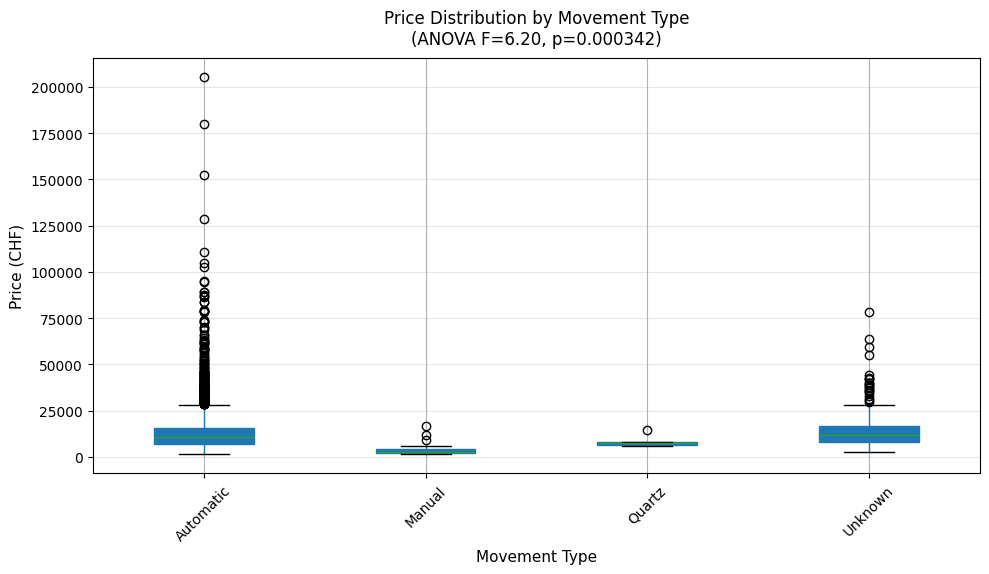

One-Way ANOVA: Price Differences Across Movement Types
  F-statistic: 6.1984
  p-value: 0.000342

Descriptive Statistics by Movement Type:
                   mean   median       std  count
movement_type                                    
Automatic      14094.42  10465.0  14031.94   2098
Manual          3786.68   2821.0   3306.48     31
Quartz          8482.00   7612.0   3319.54      5
Unknown        14469.70  11699.0  10678.25    239

Interpretation:
  There are statistically significant price differences across movement types (p < 0.05).


In [22]:
movement_groups = [group['price'].values for name, group in df.groupby('movement_type') if len(group) >= 2]

if len(movement_groups) >= 2:
    f_stat_movement, p_val_movement = f_oneway(*movement_groups)
    
    plt.figure(figsize=(10, 6))
    df.boxplot(column='price', by='movement_type', figsize=(10, 6), patch_artist=True)
    plt.suptitle('')
    plt.title(f'Price Distribution by Movement Type\n(ANOVA F={f_stat_movement:.2f}, p={p_val_movement:.6f})', 
              fontsize=12, pad=10)
    plt.xlabel('Movement Type', fontsize=11)
    plt.ylabel('Price (CHF)', fontsize=11)
    plt.xticks(rotation=45)
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    print(f"One-Way ANOVA: Price Differences Across Movement Types")
    print(f"  F-statistic: {f_stat_movement:.4f}")
    print(f"  p-value: {p_val_movement:.6f}")
    print(f"\nDescriptive Statistics by Movement Type:")
    movement_stats = df.groupby('movement_type')['price'].agg(['mean', 'median', 'std', 'count'])
    print(movement_stats.round(2))
    print(f"\nInterpretation:")
    if p_val_movement < 0.05:
        print(f"  There are statistically significant price differences across movement types (p < 0.05).")
    else:
        print(f"  There are no statistically significant price differences across movement types (p >= 0.05).")
else:
    print("Not enough movement type groups for ANOVA analysis.")

### Interpretation

The ANOVA tests reveal whether there are statistically significant price differences across different categorical groups. A p-value < 0.05 indicates that at least one group has a significantly different mean price than the others.

## 3. Chi-Squared Test for Categorical Associations

### 3.1 Chi-Squared Test: Condition vs Material

Chi-Squared Test: Condition vs Material Category
  Chi-squared statistic: 250.3565
  p-value: 0.000000
  Degrees of freedom: 24

Contingency Table:
material_category   Gold/Steel  Other  Platinum  Rose Gold  Steel  White Gold  \
condition_category                                                              
Fair                         3      4         1          1     97           2   
Good                        52     66         1         23    305          12   
New                         31     17         4         13    257           9   
Unknown                      7     61         1         13     68           7   
Very Good                  209    101         7         35    727          45   

material_category   Yellow Gold  
condition_category               
Fair                         11  
Good                         38  
New                          14  
Unknown                       5  
Very Good                   126  

Interpretation:
  There is a statistically si

<Figure size 1200x600 with 0 Axes>

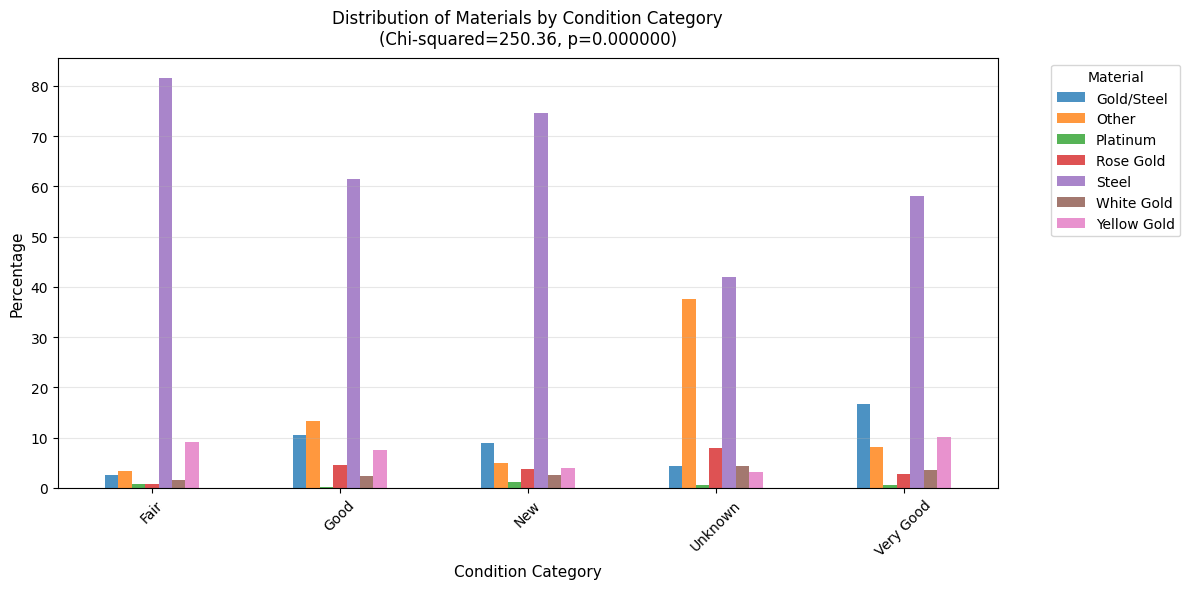

In [23]:
contingency_table = pd.crosstab(df['condition_category'], df['material_category'])

chi2, p_value_chi, dof, expected = chi2_contingency(contingency_table)

print(f"Chi-Squared Test: Condition vs Material Category")
print(f"  Chi-squared statistic: {chi2:.4f}")
print(f"  p-value: {p_value_chi:.6f}")
print(f"  Degrees of freedom: {dof}")
print(f"\nContingency Table:")
print(contingency_table)
print(f"\nInterpretation:")
if p_value_chi < 0.05:
    print(f"  There is a statistically significant association between condition and material (p < 0.05).")
    print(f"  The distribution of materials differs significantly across condition categories.")
else:
    print(f"  There is no statistically significant association between condition and material (p >= 0.05).")
    print(f"  Condition and material are independent.")

plt.figure(figsize=(12, 6))
contingency_pct = contingency_table.div(contingency_table.sum(axis=1), axis=0) * 100
contingency_pct.plot(kind='bar', stacked=False, figsize=(12, 6), alpha=0.8)
plt.title(f'Distribution of Materials by Condition Category\n(Chi-squared={chi2:.2f}, p={p_value_chi:.6f})', 
          fontsize=12, pad=10)
plt.xlabel('Condition Category', fontsize=11)
plt.ylabel('Percentage', fontsize=11)
plt.xticks(rotation=45)
plt.legend(title='Material', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### 3.2 Chi-Squared Test: Condition vs Seller Type

Chi-Squared Test: Condition vs Seller Type
  Chi-squared statistic: 727.0064
  p-value: 0.000000
  Degrees of freedom: 8

Contingency Table:
seller_type         Partner Certified Included  Private Seller  \
condition_category                                               
Fair                                        91               0   
Good                                        35               4   
New                                          0              45   
Unknown                                      0               0   
Very Good                                  568              27   

seller_type         Professional dealer  
condition_category                       
Fair                                 28  
Good                                458  
New                                 300  
Unknown                             162  
Very Good                           655  

Interpretation:
  There is a statistically significant association between condition and seller type 

<Figure size 1000x600 with 0 Axes>

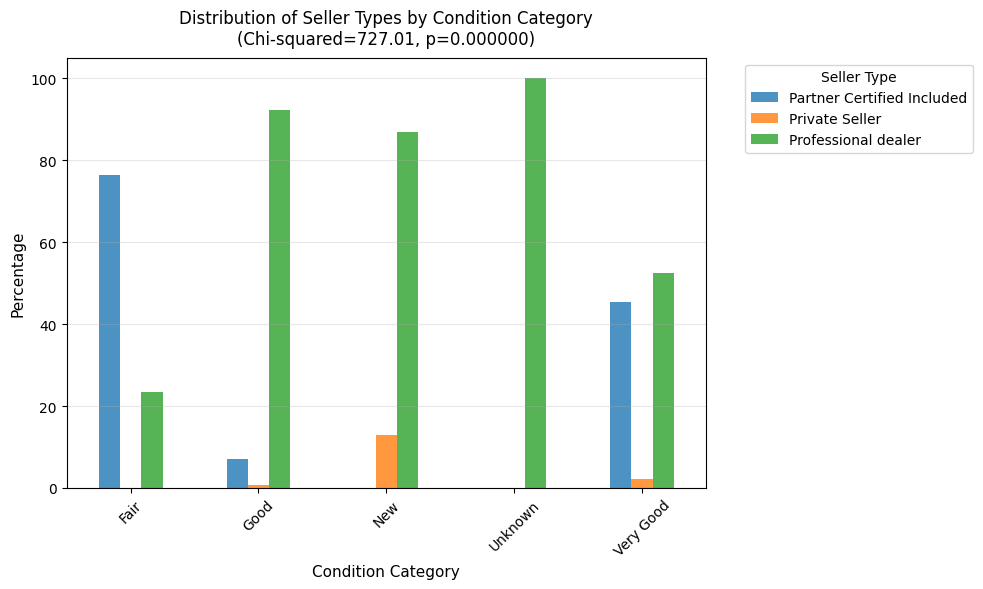

In [24]:
contingency_table2 = pd.crosstab(df['condition_category'], df['seller_type'])

chi2_2, p_value_chi2, dof2, expected2 = chi2_contingency(contingency_table2)

print(f"Chi-Squared Test: Condition vs Seller Type")
print(f"  Chi-squared statistic: {chi2_2:.4f}")
print(f"  p-value: {p_value_chi2:.6f}")
print(f"  Degrees of freedom: {dof2}")
print(f"\nContingency Table:")
print(contingency_table2)
print(f"\nInterpretation:")
if p_value_chi2 < 0.05:
    print(f"  There is a statistically significant association between condition and seller type (p < 0.05).")
    print(f"  Professional dealers and private sellers have different distributions of watch conditions.")
else:
    print(f"  There is no statistically significant association between condition and seller type (p >= 0.05).")
    print(f"  Condition and seller type are independent.")

plt.figure(figsize=(10, 6))
contingency_pct2 = contingency_table2.div(contingency_table2.sum(axis=1), axis=0) * 100
contingency_pct2.plot(kind='bar', stacked=False, figsize=(10, 6), alpha=0.8)
plt.title(f'Distribution of Seller Types by Condition Category\n(Chi-squared={chi2_2:.2f}, p={p_value_chi2:.6f})', 
          fontsize=12, pad=10)
plt.xlabel('Condition Category', fontsize=11)
plt.ylabel('Percentage', fontsize=11)
plt.xticks(rotation=45)
plt.legend(title='Seller Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### 3.3 Chi-Squared Test: Material vs Movement Type

In [25]:
contingency_table3 = pd.crosstab(df['material_category'], df['movement_type'])

chi2_3, p_value_chi3, dof3, expected3 = chi2_contingency(contingency_table3)

print(f"Chi-Squared Test: Material vs Movement Type")
print(f"  Chi-squared statistic: {chi2_3:.4f}")
print(f"  p-value: {p_value_chi3:.6f}")
print(f"  Degrees of freedom: {dof3}")
print(f"\nContingency Table:")
print(contingency_table3)
print(f"\nInterpretation:")
if p_value_chi3 < 0.05:
    print(f"  There is a statistically significant association between material and movement type (p < 0.05).")
    print(f"  Different materials are associated with different movement types.")
else:
    print(f"  There is no statistically significant association between material and movement type (p >= 0.05).")
    print(f"  Material and movement type are independent.")

Chi-Squared Test: Material vs Movement Type
  Chi-squared statistic: 73.8713
  p-value: 0.000000
  Degrees of freedom: 18

Contingency Table:
movement_type      Automatic  Manual  Quartz  Unknown
material_category                                    
Gold/Steel               254       0       1       47
Other                    197       2       0       50
Platinum                  12       0       0        2
Rose Gold                 82       1       0        2
Steel                   1319      17       3      115
White Gold                66       3       0        6
Yellow Gold              168       8       1       17

Interpretation:
  There is a statistically significant association between material and movement type (p < 0.05).
  Different materials are associated with different movement types.


### 3.4 Chi-Squared Test: Has Complete Set vs Seller Type

Chi-Squared Test: Complete Documentation vs Seller Type
  Chi-squared statistic: 0.0000
  p-value: 1.000000
  Degrees of freedom: 0

Contingency Table:
seller_type             Partner Certified Included  Private Seller  \
has_complete_set_label                                               
Complete Set                                   694              76   

seller_type             Professional dealer  
has_complete_set_label                       
Complete Set                           1603  

Interpretation:
  There is no statistically significant association between complete documentation and seller type (p >= 0.05).


<Figure size 800x500 with 0 Axes>

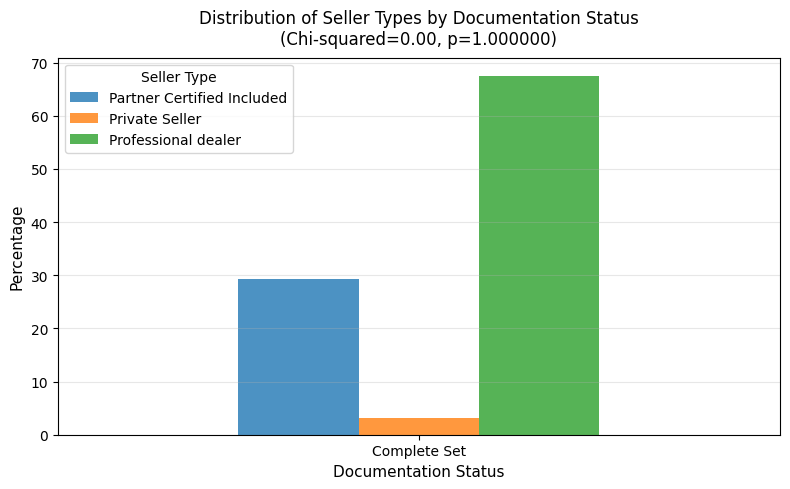

In [26]:
df['has_complete_set_label'] = df['has_complete_set'].map({0: 'No Complete Set', 1: 'Complete Set'})
contingency_table4 = pd.crosstab(df['has_complete_set_label'], df['seller_type'])

chi2_4, p_value_chi4, dof4, expected4 = chi2_contingency(contingency_table4)

print(f"Chi-Squared Test: Complete Documentation vs Seller Type")
print(f"  Chi-squared statistic: {chi2_4:.4f}")
print(f"  p-value: {p_value_chi4:.6f}")
print(f"  Degrees of freedom: {dof4}")
print(f"\nContingency Table:")
print(contingency_table4)
print(f"\nInterpretation:")
if p_value_chi4 < 0.05:
    print(f"  There is a statistically significant association between complete documentation and seller type (p < 0.05).")
    print(f"  Professional dealers and private sellers differ in the proportion of complete sets they offer.")
else:
    print(f"  There is no statistically significant association between complete documentation and seller type (p >= 0.05).")

plt.figure(figsize=(8, 5))
contingency_pct4 = contingency_table4.div(contingency_table4.sum(axis=1), axis=0) * 100
contingency_pct4.plot(kind='bar', stacked=False, figsize=(8, 5), alpha=0.8)
plt.title(f'Distribution of Seller Types by Documentation Status\n(Chi-squared={chi2_4:.2f}, p={p_value_chi4:.6f})', 
          fontsize=12, pad=10)
plt.xlabel('Documentation Status', fontsize=11)
plt.ylabel('Percentage', fontsize=11)
plt.xticks(rotation=0)
plt.legend(title='Seller Type')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### Interpretation

Chi-squared tests assess whether there are statistically significant associations between categorical variables. A p-value < 0.05 indicates that the two variables are not independent - they have a significant relationship.

## Jupyter notebook --footer info-- (please always provide this at the end of each submitted notebook)

In [27]:
import os
import platform
from platform import python_version
from datetime import datetime

print('-----------------------------------')
print(os.name.upper())
print(platform.system(), '|', platform.release())
print('Datetime:', datetime.now().strftime("%Y-%m-%d %H:%M:%S"))
print('Python Version:', python_version())
print('-----------------------------------')

-----------------------------------
POSIX
Darwin | 25.2.0
Datetime: 2025-12-28 11:35:35
Python Version: 3.11.13
-----------------------------------
